# Uganda Rainfall Variability & Drought Analysis
**Data source:** CHIRPS Daily Precipitation (UC Santa Barbara Climate Hazards Group), exported via Google Earth Engine
**Period:** January 1990 – December 2025
**Spatial scope:** National boundary average, Uganda

This notebook covers two passes over the same dataset:

1. **Part 1 — Core report:** long-term trend, annual totals, drought identification, seasonal (MAM vs SON) comparison.
2. **Part 2 — Exploratory extensions:** climatology, decadal comparison, variability over time, trend decomposition, multi-month drought duration (SPI-3), a year×month heatmap, ENSO correlation, and autocorrelation/persistence.

Each finding is written up in a markdown cell immediately after the code and output that produced it.

## Setup

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('../data/raw/uganda_monthly_rainfall.csv')
df = df[['date', 'month', 'year', 'rainfall_mm']].copy()
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['date_dt'] = pd.to_datetime(df['date'])
df = df.sort_values('date_dt').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Range: {df['date_dt'].min().date()} to {df['date_dt'].max().date()}")
print(f"Missing values: {df['rainfall_mm'].isna().sum()}")
df['rainfall_mm'].describe()

Rows: 432
Range: 1990-01-01 to 2025-12-01
Missing values: 0


count    432.000000
mean     103.419306
std       45.617330
min        9.636560
25%       68.236004
50%      104.647246
75%      135.587104
max      246.310655
Name: rainfall_mm, dtype: float64

In [3]:
# Calendar-month climatology, used as the anomaly baseline throughout
clim = df.groupby('month')['rainfall_mm'].agg(['mean', 'std']).rename(
    columns={'mean': 'clim_mean', 'std': 'clim_std'})
df = df.merge(clim, on='month', how='left')
df['anomaly_mm'] = df['rainfall_mm'] - df['clim_mean']
df['std_anomaly'] = df['anomaly_mm'] / df['clim_std']
df.head()

,date,month,year,rainfall_mm,date_dt,clim_mean,clim_std,anomaly_mm,std_anomaly
0,1990-01,1,1990,38.171323,1990-01-01,38.200139,14.982134,-0.028816,-0.001923
1,1990-02,2,1990,75.068931,1990-02-01,41.375220,18.855642,33.693711,1.786930
2,1990-03,3,1990,128.933294,1990-03-01,105.264519,27.889925,23.668775,0.848650
3,1990-04,4,1990,165.834233,1990-04-01,166.499863,30.060016,-0.665630,-0.022143
4,1990-05,5,1990,136.083761,1990-05-01,144.950687,23.987212,-8.866927,-0.369652


---
## Part 1 — Core Report

### 1.1 Monthly rainfall, full record

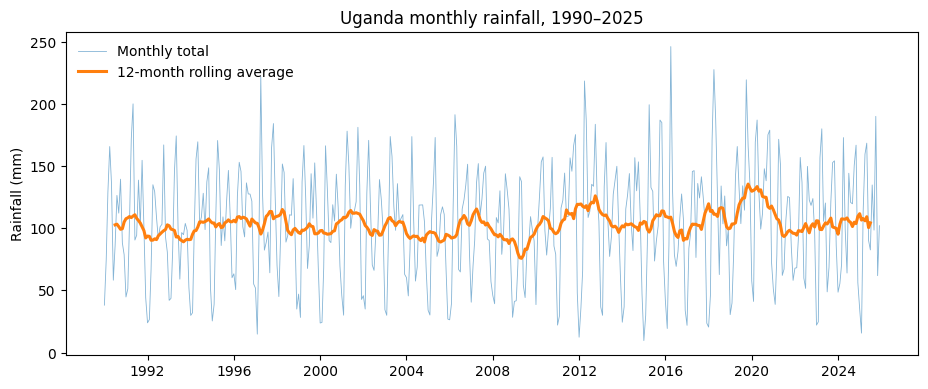

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(df['date_dt'], df['rainfall_mm'], linewidth=0.6, alpha=0.55, label='Monthly total')
roll = df['rainfall_mm'].rolling(12, center=True).mean()
ax.plot(df['date_dt'], roll, linewidth=2.2, label='12-month rolling average')
ax.set_ylabel('Rainfall (mm)')
ax.set_title('Uganda monthly rainfall, 1990–2025')
ax.legend(frameon=False)
plt.show()

The 12-month rolling average dips to its lowest sustained trough around 2008–2009, then trends upward through the late 2010s before easing back toward the long-run average in recent years.

### 1.2 Annual totals and linear trend

Trend: +2.61 mm/year   R²=0.063   p=0.1398
Mean annual rainfall: 1241.0 mm
Driest year: 2009 (999.7 mm)
Wettest year: 2020 (1508.5 mm)


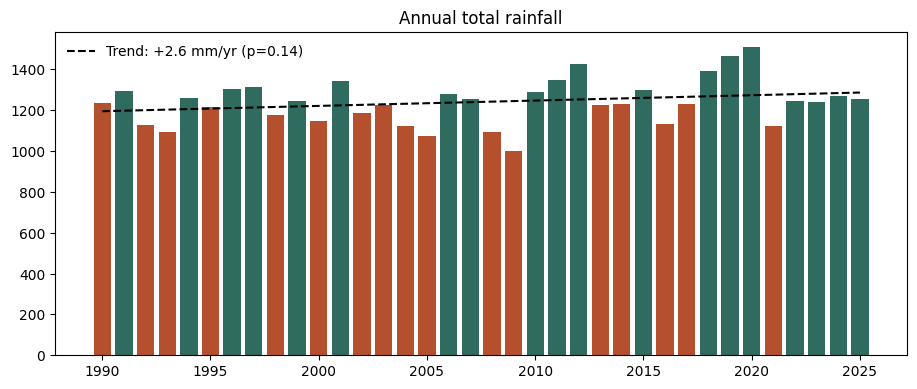

In [5]:
counts = df.groupby('year').size()
full_years = counts[counts == 12].index
annual = df[df['year'].isin(full_years)].groupby('year')['rainfall_mm'].sum().reset_index()

slope, intercept, r, p, se = stats.linregress(annual['year'], annual['rainfall_mm'])
print(f"Trend: {slope:+.2f} mm/year   R²={r**2:.3f}   p={p:.4f}")
print(f"Mean annual rainfall: {annual['rainfall_mm'].mean():.1f} mm")
print(f"Driest year: {annual.loc[annual['rainfall_mm'].idxmin(), 'year']:.0f} "
      f"({annual['rainfall_mm'].min():.1f} mm)")
print(f"Wettest year: {annual.loc[annual['rainfall_mm'].idxmax(), 'year']:.0f} "
      f"({annual['rainfall_mm'].max():.1f} mm)")

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#B5502E' if v < annual['rainfall_mm'].mean() else '#2F6B5E' for v in annual['rainfall_mm']]
ax.bar(annual['year'], annual['rainfall_mm'], color=colors)
ax.plot(annual['year'], slope * annual['year'] + intercept, 'k--', label=f'Trend: {slope:+.1f} mm/yr (p={p:.2f})')
ax.legend(frameon=False)
ax.set_title('Annual total rainfall')
plt.show()

**Finding:** no statistically significant long-term trend in national annual rainfall (p=0.14). The gap between the driest year (2009) and wettest (2020) is just over 500mm — roughly 40% of an average year's total — which is the more consequential story than the flat multi-decade trend.

### 1.3 Drought identification (standardized monthly anomaly)

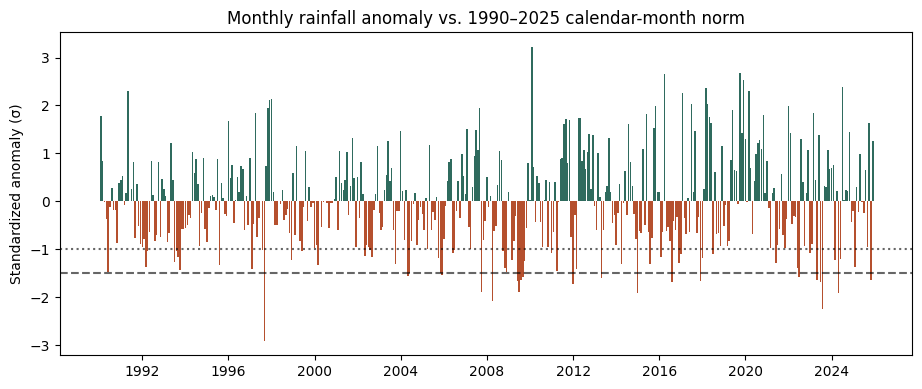

Years with most moderate-deficit months (≤ -1σ):
year
2009    6
2008    4
1993    4
2023    4
2005    4
Name: drought_moderate, dtype: int64


In [6]:
df['drought_moderate'] = df['std_anomaly'] <= -1.0
df['drought_severe'] = df['std_anomaly'] <= -1.5

fig, ax = plt.subplots(figsize=(11, 4.2))
colors = ['#B5502E' if v < 0 else '#2F6B5E' for v in df['std_anomaly']]
ax.bar(df['date_dt'], df['std_anomaly'], color=colors, width=25)
ax.axhline(-1, linestyle=':', color='k', alpha=0.6)
ax.axhline(-1.5, linestyle='--', color='k', alpha=0.6)
ax.set_ylabel('Standardized anomaly (σ)')
ax.set_title('Monthly rainfall anomaly vs. 1990–2025 calendar-month norm')
plt.show()

drought_by_year = df.groupby('year')['drought_moderate'].sum().sort_values(ascending=False)
print("Years with most moderate-deficit months (≤ -1σ):")
print(drought_by_year.head(5))

**Finding:** 2009 is the clear worst drought year (6 moderate-deficit months, 4 of them severe), part of a broader 2008–2009 episode. 2023 is the most significant recent drought year, tied for second-most deficit months of the record.

### 1.4 Seasonal comparison — the two rainy seasons

MAM (long rains):  mean=416.7mm  trend=+0.34mm/yr  p=0.6739
SON (short rains): mean=377.8mm  trend=+1.64mm/yr  p=0.0643


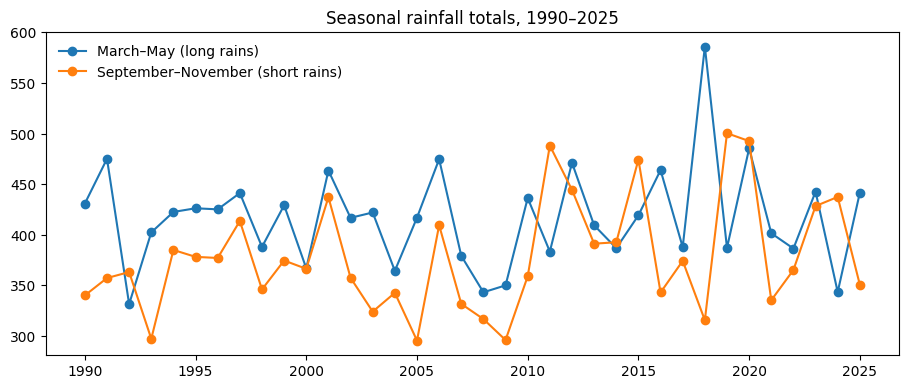

In [7]:
mam = df[df['month'].isin([3, 4, 5])].groupby('year')['rainfall_mm'].sum()
son = df[df['month'].isin([9, 10, 11])].groupby('year')['rainfall_mm'].sum()

sl_mam, _, _, p_mam, _ = stats.linregress(mam.index, mam.values)
sl_son, _, _, p_son, _ = stats.linregress(son.index, son.values)
print(f"MAM (long rains):  mean={mam.mean():.1f}mm  trend={sl_mam:+.2f}mm/yr  p={p_mam:.4f}")
print(f"SON (short rains): mean={son.mean():.1f}mm  trend={sl_son:+.2f}mm/yr  p={p_son:.4f}")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(mam.index, mam.values, marker='o', label='March–May (long rains)')
ax.plot(son.index, son.values, marker='o', label='September–November (short rains)')
ax.legend(frameon=False)
ax.set_title('Seasonal rainfall totals, 1990–2025')
plt.show()

**Finding:** the short rains (SON) show a mild, borderline-significant upward trend. The long rains (MAM) — the more critical planting season for much of the country — show no trend and more year-to-year volatility. A stable national annual average conceals a planting season becoming less predictable.

---
## Part 2 — Exploratory Extensions

A wider pass through the same series: what else can this dataset answer?

### 2.1 Monthly climatology

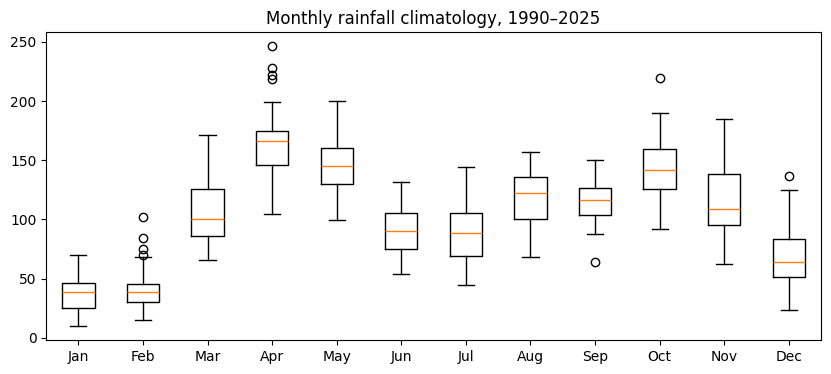

,mean,std,min,max
month,,,,
1,38.2,15.0,9.6,70.2
2,41.4,18.9,14.8,102.2
3,105.3,27.9,65.7,171.1
4,166.5,30.1,104.3,246.3
5,145.0,24.0,99.1,200.2
6,90.2,21.8,54.2,131.8
7,88.5,23.5,44.3,144.3
8,120.0,22.8,68.6,156.9
9,115.6,17.7,64.2,150.0


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
data_by_month = [df[df['month'] == m]['rainfall_mm'].values for m in range(1, 13)]
ax.boxplot(data_by_month)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Monthly rainfall climatology, 1990–2025')
plt.show()

df.groupby('month')['rainfall_mm'].agg(['mean', 'std', 'min', 'max']).round(1)

**Finding:** April is Uganda's wettest month on average (166.5mm) and its most extreme range (104–246mm across the record). November, the peak of the short rains, is the single most variable month (std. dev. 34mm).

### 2.2 Decade-by-decade comparison

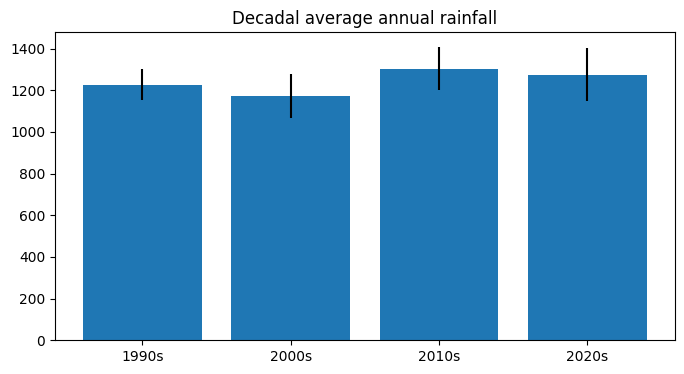

,mean,std,count
decade,,,
1990,1226.6,74.5,10
2000,1173.6,105.5,10
2010,1303.4,104.1,10
2020,1273.4,127.1,6


In [9]:
df['decade'] = (df['year'] // 10) * 10
decade_annual = df.groupby(['decade', 'year'])['rainfall_mm'].sum().reset_index()
decade_means = decade_annual.groupby('decade')['rainfall_mm'].agg(['mean', 'std', 'count']).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(decade_means.index.astype(str) + 's', decade_means['mean'], yerr=decade_means['std'])
ax.set_title('Decadal average annual rainfall')
plt.show()

decade_means

**Finding:** the 2000s were the driest decade (1,173.6mm avg), the 2010s the wettest (1,303.4mm) — a 130mm swing between adjacent decades the overall linear trend doesn't capture.

### 2.3 Is rainfall becoming more erratic?

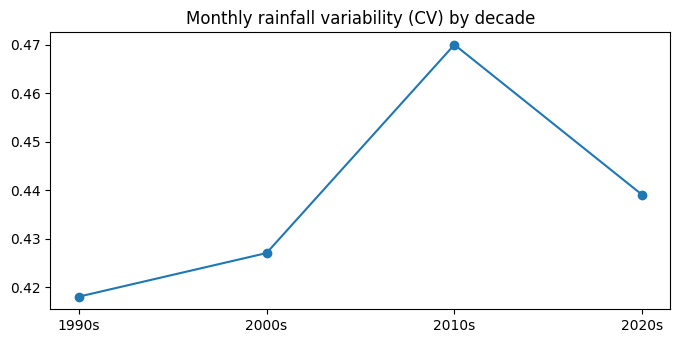

decade
1990    0.418
2000    0.427
2010    0.470
2020    0.439
Name: rainfall_mm, dtype: float64

In [10]:
cv_by_decade = df.groupby('decade')['rainfall_mm'].apply(lambda x: x.std() / x.mean()).round(3)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(cv_by_decade.index.astype(str) + 's', cv_by_decade.values, marker='o')
ax.set_title('Monthly rainfall variability (CV) by decade')
plt.show()

cv_by_decade

**Finding:** variability rose ~12% from the 1990s (CV 0.418) to the 2010s (CV 0.470), then eased slightly in the 2020s so far. Totals didn't trend, but individual months swung further from their seasonal norm than they used to.

### 2.4 Trend / seasonal / residual decomposition

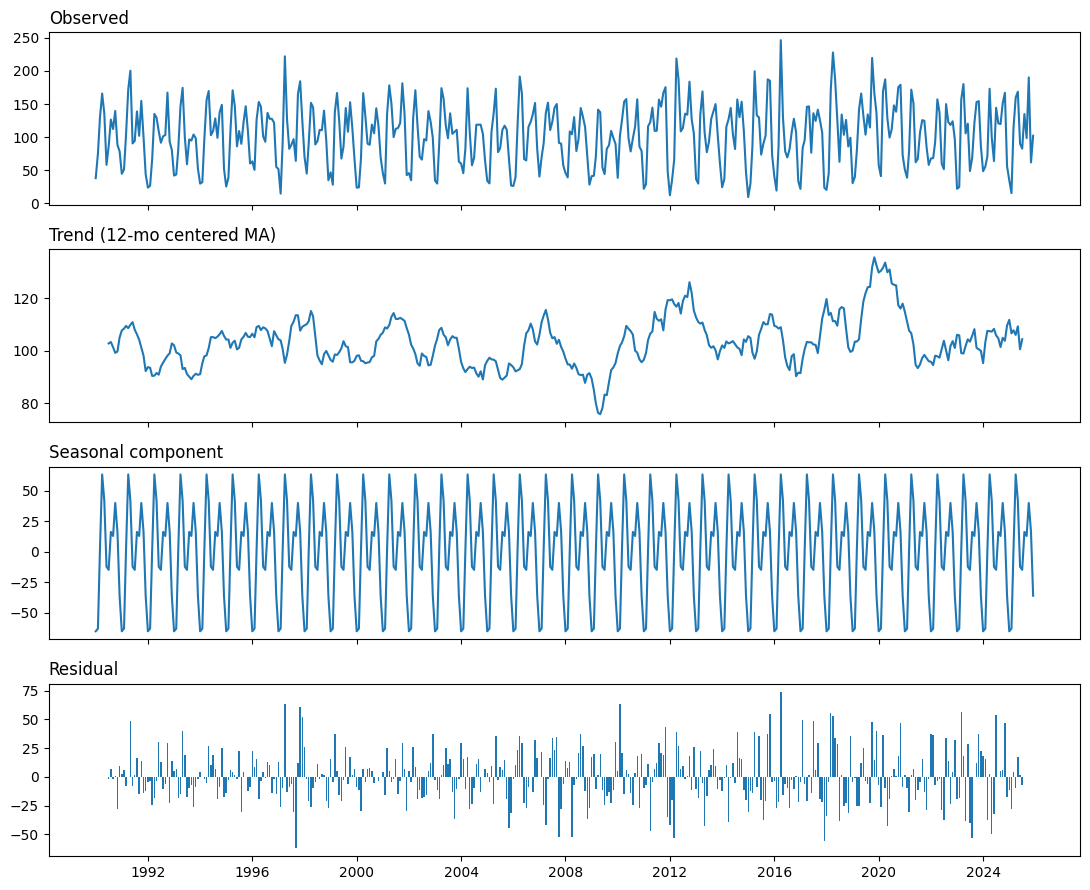

In [11]:
s = df.set_index('date_dt')['rainfall_mm']
trend = s.rolling(window=12, center=True).mean()
detrended = s - trend
seasonal_avg = detrended.groupby(detrended.index.month).mean()
seasonal = pd.Series(s.index.month.map(seasonal_avg).values, index=s.index)
residual = s - trend - seasonal

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(s.index, s.values); axes[0].set_title('Observed', loc='left')
axes[1].plot(trend.index, trend.values); axes[1].set_title('Trend (12-mo centered MA)', loc='left')
axes[2].plot(seasonal.index, seasonal.values); axes[2].set_title('Seasonal component', loc='left')
axes[3].bar(residual.index, residual.values, width=20); axes[3].set_title('Residual', loc='left')
plt.tight_layout()
plt.show()

**Finding:** with seasonal noise stripped out, the isolated trend panel shows the 2008–2009 trough and late-2010s rise far more clearly than the raw series. The residual panel shows no obvious leftover structure.

### 2.5 A stricter trend test (Kendall's tau)

In [12]:
tau, p_tau = stats.kendalltau(annual['year'], annual['rainfall_mm'])
slope, intercept, r, p_lin, se = stats.linregress(annual['year'], annual['rainfall_mm'])
print(f"Kendall tau={tau:.3f}, p={p_tau:.4f}  |  OLS slope={slope:.2f}mm/yr, p={p_lin:.4f}")

Kendall tau=0.149, p=0.2004  |  OLS slope=2.61mm/yr, p=0.1398


**Finding:** the rank-based, assumption-free Kendall test agrees with the linear regression — neither finds a significant trend. This is a reasonable robustness check on the headline "no significant trend" finding.

### 2.6 How long do droughts actually last? (SPI-3 approximation)

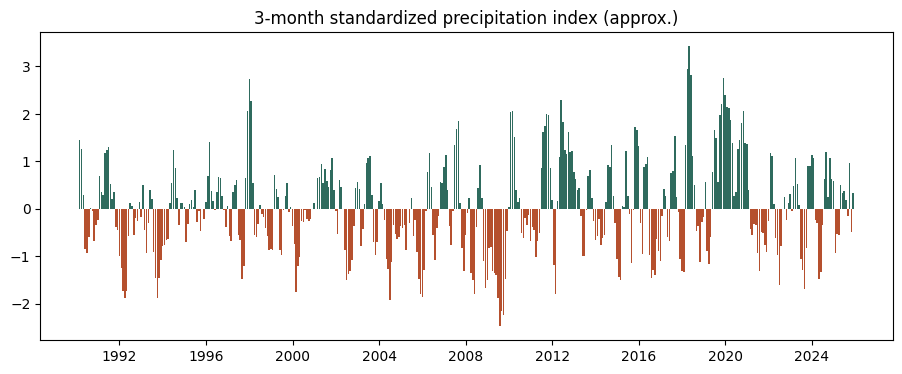

,start,end,length,min_spi3
streak_id,,,,
24,2009-04-01,2009-11-01,8,-2.471067
2,1992-02-01,1992-05-01,4,-1.884148
10,2002-07-01,2002-10-01,4,-1.486655
12,2004-05-01,2004-08-01,4,-1.915426
14,2005-11-01,2006-02-01,4,-1.851105


In [13]:
roll3 = s.rolling(3).sum()
roll3_df = pd.DataFrame({'date': roll3.index, 'roll3': roll3.values})
roll3_df['month'] = roll3_df['date'].dt.month
clim3 = roll3_df.groupby('month')['roll3'].agg(['mean', 'std'])
roll3_df = roll3_df.merge(clim3, on='month')
roll3_df['spi3'] = (roll3_df['roll3'] - roll3_df['mean']) / roll3_df['std']
roll3_df['drought'] = roll3_df['spi3'] <= -1.0
roll3_df['streak_id'] = (roll3_df['drought'] != roll3_df['drought'].shift()).cumsum()

episodes = roll3_df[roll3_df['drought']].groupby('streak_id').agg(
    start=('date', 'first'), end=('date', 'last'),
    length=('drought', 'sum'), min_spi3=('spi3', 'min')
).sort_values('length', ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#B5502E' if v < 0 else '#2F6B5E' for v in roll3_df['spi3'].fillna(0)]
ax.bar(roll3_df['date'], roll3_df['spi3'], color=colors, width=25)
ax.set_title('3-month standardized precipitation index (approx.)')
plt.show()

episodes.head(5)

**Finding — the most significant revision in this notebook:** viewed as a rolling 3-month deficit rather than isolated months, the 2009 drought ran continuously for **8 months (April–November)**, notably longer and more severe (min. −2.47σ) than the single-month view in Part 1 suggested.

### 2.7 The full picture: year × month heatmap

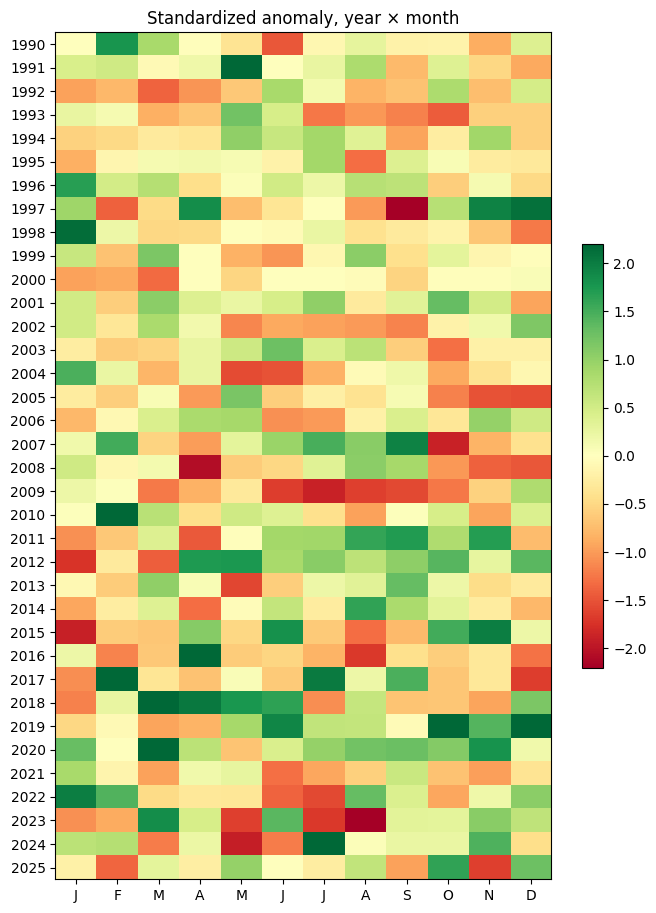

In [14]:
pivot = df.pivot(index='year', columns='month', values='std_anomaly')

fig, ax = plt.subplots(figsize=(8, 11))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-2.2, vmax=2.2, aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(list('JFMAMJJASOND'))
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title('Standardized anomaly, year × month')
fig.colorbar(im, ax=ax, shrink=0.5)
plt.show()

**Finding:** the clearest visual cluster is the red band at 2008–2009. Beyond that, deficit months are scattered fairly evenly across the 36-year grid rather than concentrated in one era or one recurring calendar month.

### 2.8 Does ENSO explain Uganda's rainfall swings?

El Niño  (n=11): mean SON rainfall = 379.3mm
Neutral (n=10): mean SON rainfall = 382.5mm
La Niña  (n=15): mean SON rainfall = 373.6mm
t-test (El Niño vs La Niña): p = 0.7963


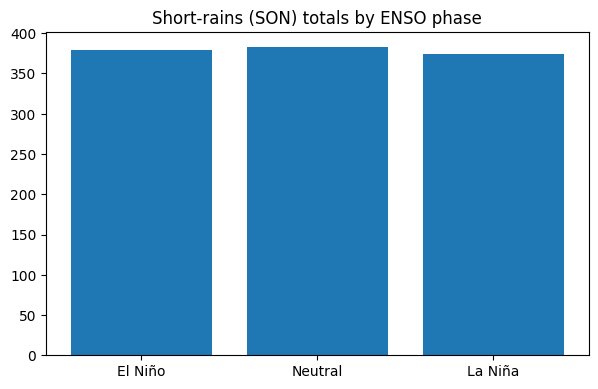

In [15]:
# Approximate NOAA ONI/RONI-classified years (year = the year the OND season falls in)
EL_NINO_YEARS = [1991, 1994, 1997, 2002, 2004, 2006, 2009, 2014, 2015, 2018, 2023]
LA_NINA_YEARS = [1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2016, 2017, 2020, 2021, 2022, 2024]

son = df[df['month'].isin([9, 10, 11])].groupby('year')['rainfall_mm'].sum()
el_nino = son[son.index.isin(EL_NINO_YEARS)]
la_nina = son[son.index.isin(LA_NINA_YEARS)]
neutral = son[~son.index.isin(EL_NINO_YEARS + LA_NINA_YEARS)]

t_stat, t_p = stats.ttest_ind(el_nino.dropna(), la_nina.dropna())
print(f"El Niño  (n={len(el_nino)}): mean SON rainfall = {el_nino.mean():.1f}mm")
print(f"Neutral (n={len(neutral)}): mean SON rainfall = {neutral.mean():.1f}mm")
print(f"La Niña  (n={len(la_nina)}): mean SON rainfall = {la_nina.mean():.1f}mm")
print(f"t-test (El Niño vs La Niña): p = {t_p:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['El Niño', 'Neutral', 'La Niña'], [el_nino.mean(), neutral.mean(), la_nina.mean()])
ax.set_title('Short-rains (SON) totals by ENSO phase')
plt.show()

**Finding (null result):** at the national-average scale, ENSO phase does not produce a statistically distinguishable difference in Uganda's short-rains totals (p=0.80). The documented ENSO–East Africa rainfall relationship is real regionally, but likely too diluted by whole-country averaging to show up here — a regional breakdown would be a better test.

### 2.9 Does one wet or dry month predict the next?

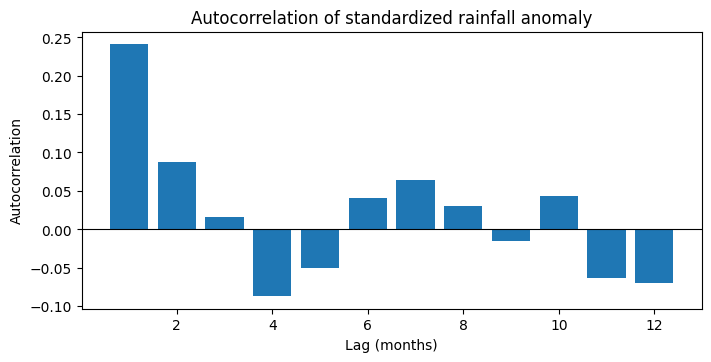

{1: 0.241,
 2: 0.088,
 3: 0.016,
 4: -0.087,
 5: -0.05,
 6: 0.041,
 7: 0.064,
 8: 0.03,
 9: -0.015,
 10: 0.043,
 11: -0.064,
 12: -0.071}

In [16]:
anom = df['std_anomaly'].values
acf = {lag: np.corrcoef(anom[:-lag], anom[lag:])[0, 1] for lag in range(1, 13)}

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(list(acf.keys()), list(acf.values()))
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Lag (months)'); ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation of standardized rainfall anomaly')
plt.show()

{k: round(v, 3) for k, v in acf.items()}

**Finding:** weak but real 1-month persistence (r=0.241), decaying to near zero by lag 2. This dataset alone gives little basis for forecasting drought more than about a month ahead — longer-range forecasting needs external predictors (ENSO indices, soil moisture, SST).

---
## Summary — what this dataset can and can't answer

**Well suited for:**
- Long-term trend and significance testing (annual/seasonal)
- Seasonal climatology — when the rains typically fall
- Identifying and ranking historical drought/surplus episodes
- Decadal comparison and variability (CV) tracking
- Multi-month drought duration and severity (SPI-style)
- Testing broad climate-driver hypotheses (e.g. ENSO) at low resolution

**Not suited for:**
- Sub-national or district-level drought risk (Karamoja is masked by the national average)
- Attributing any single year's cause (ENSO, IOD, land-use change) with confidence
- Forecasting beyond ~1 month using rainfall alone (weak autocorrelation)
- Crop-specific impact — needs soil type, planting calendar, crop water requirements
- Extreme daily events (flooding, single-storm intensity) — this is monthly-aggregated data
- Formal climate-change attribution — 36 years is short for separating trend from natural multi-decadal variability

**Suggested next step:** re-run this same pipeline with the Earth Engine boundary swapped to a specific region (Karamoja, the Lake Victoria basin, or Uganda's agro-ecological zones). The national average likely smooths over the sharpest regional droughts and the clearest ENSO signal — both came back weaker than expected at the country-wide scale.

---
*ENSO year classification is an approximation based on NOAA ONI/RONI thresholds and may differ slightly by index or source. SPI-3 here is a simplified z-score approximation, not a full Gamma-distribution-fitted SPI.*